In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU available: []


In [2]:
# Dataset paths

TRAIN_DIR = "../data/train"
VALID_DIR = "../data/valid"
TEST_DIR = "../data/test"

print("Training directory:", TRAIN_DIR)
print("Validation directory:", VALID_DIR)
print("Testing directory:", TEST_DIR)

Training directory: ../data/train
Validation directory: ../data/valid
Testing directory: ../data/test


In [3]:
# Image settings

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_dataset = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Dataset loaded successfully!")

Found 3208 files belonging to 20 classes.
Found 100 files belonging to 20 classes.
Found 100 files belonging to 20 classes.
Dataset loaded successfully!


In [4]:
class_names = train_dataset.class_names

print("Number of bird species:", len(class_names))
print("\nBird species:")

for i, name in enumerate(class_names):
    print(i, ":", name)

Number of bird species: 20

Bird species:
0 : ABBOTTS BABBLER
1 : ABBOTTS BOOBY
2 : ABYSSINIAN GROUND HORNBILL
3 : AFRICAN CROWNED CRANE
4 : AFRICAN EMERALD CUCKOO
5 : AFRICAN FIREFINCH
6 : AFRICAN OYSTER CATCHER
7 : AFRICAN PIED HORNBILL
8 : AFRICAN PYGMY GOOSE
9 : ALBATROSS
10 : ALBERTS TOWHEE
11 : ALEXANDRINE PARAKEET
12 : ALPINE CHOUGH
13 : ALTAMIRA YELLOWTHROAT
14 : AMERICAN AVOCET
15 : AMERICAN BITTERN
16 : AMERICAN COOT
17 : AMERICAN FLAMINGO
18 : AMERICAN GOLDFINCH
19 : AMERICAN KESTREL


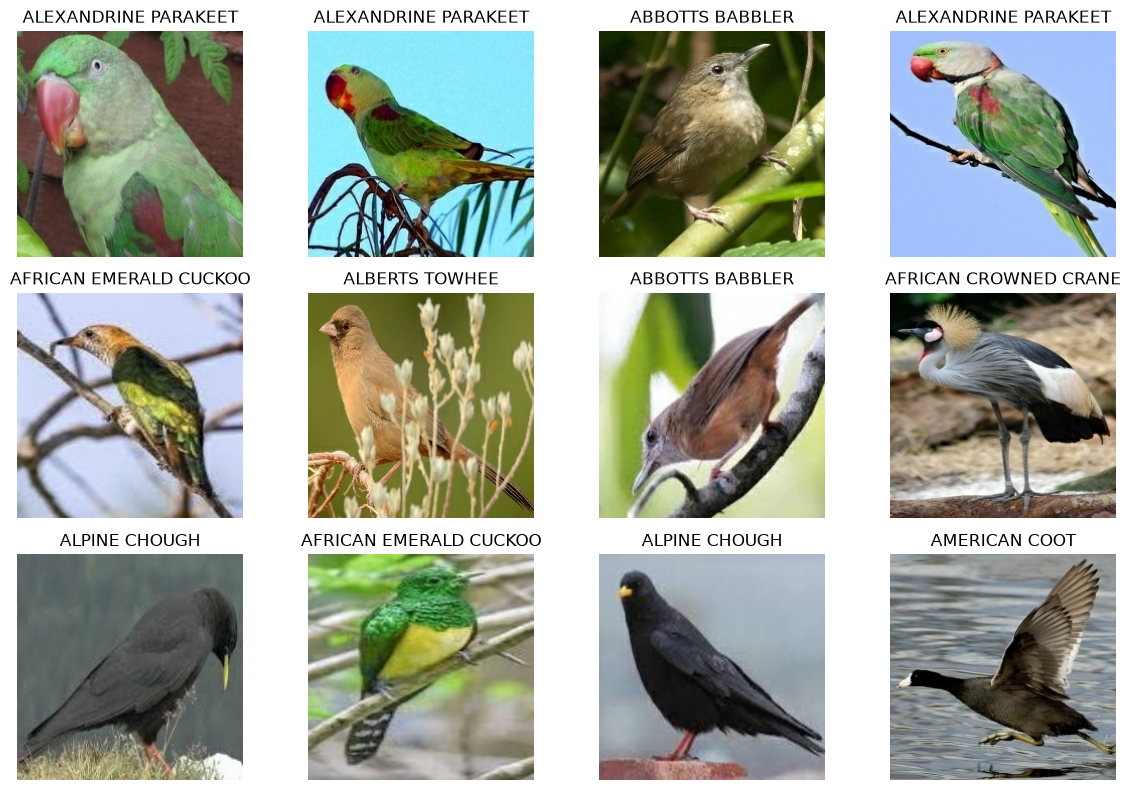

In [5]:
plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Build CNN model

model = keras.Sequential([
    
    # Normalize pixel values
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # Output layer - 20 bird species
    layers.Dense(len(class_names), activation="softmax")
])

model.summary()

d:\DataScience_Projects\03_Bird_Species_Classification\venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,171,540 (42.62 MB)

 Trainable params: 11,171,540 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compile the model

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [8]:
# Train the CNN model

EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS
)

Epoch 1/10


d:\DataScience_Projects\03_Bird_Species_Classification\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


101/101 ━━━━━━━━━━━━━━━━━━━━ 39s 377ms/step - accuracy: 0.1393 - loss: 2.8260 - val_accuracy: 0.2600 - val_loss: 2.3961
Epoch 2/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 38s 374ms/step - accuracy: 0.3239 - loss: 2.2297 - val_accuracy: 0.4900 - val_loss: 1.6204
Epoch 3/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 37s 364ms/step - accuracy: 0.4857 - loss: 1.6772 - val_accuracy: 0.6100 - val_loss: 1.2356
Epoch 4/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 39s 387ms/step - accuracy: 0.6156 - loss: 1.2445 - val_accuracy: 0.7200 - val_loss: 0.9927
Epoch 5/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 38s 372ms/step - accuracy: 0.6727 - loss: 1.0243 - val_accuracy: 0.6600 - val_loss: 0.9869
Epoch 6/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 40s 396ms/step - accuracy: 0.7547 - loss: 0.7754 - val_accuracy: 0.7500 - val_loss: 0.8221
Epoch 7/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 41s 406ms/step - accuracy: 0.7924 - loss: 0.6316 - val_accuracy: 0.7300 - val_loss: 0.8366
Epoch 8/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 38s 376ms/step - accuracy: 0.8261 - loss: 0.5240 - val

In [9]:
# Display final training results

train_accuracy = history.history["accuracy"][-1]
val_accuracy = history.history["val_accuracy"][-1]

print(f"Final Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Final Validation Accuracy: {val_accuracy * 100:.2f}%")

Final Training Accuracy: 87.13%
Final Validation Accuracy: 82.00%


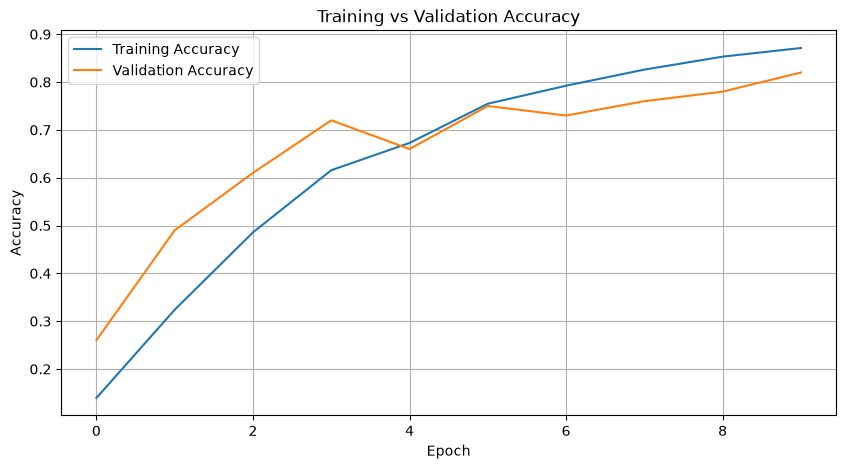

In [10]:
# Plot training and validation accuracy

plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

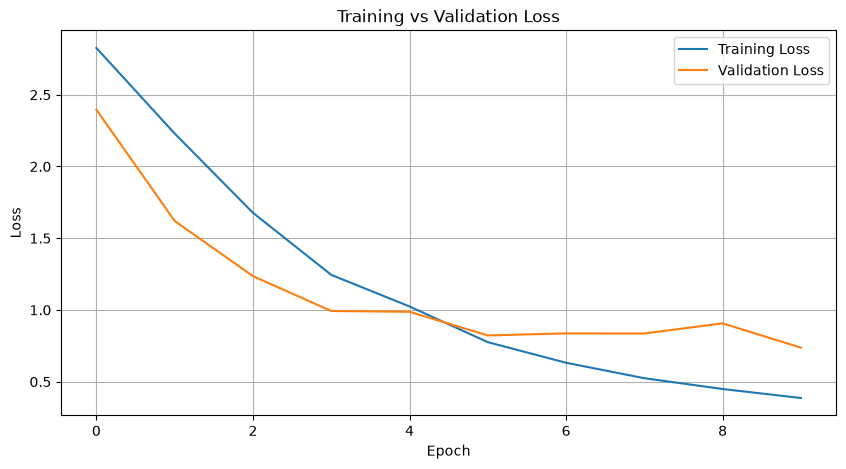

In [11]:
# Plot training and validation loss

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [12]:
# Evaluate model on test dataset

test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7400 - loss: 0.8145
Test Loss: 0.8145
Test Accuracy: 74.00%


In [13]:
# Generate predictions for the test dataset

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully!")
print("Number of test images:", len(y_true))

Predictions generated successfully!
Number of test images: 100


In [14]:
from sklearn.metrics import classification_report

print("Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

Classification Report:

                            precision    recall  f1-score   support

           ABBOTTS BABBLER       1.00      0.40      0.57         5
             ABBOTTS BOOBY       0.40      0.40      0.40         5
ABYSSINIAN GROUND HORNBILL       0.67      0.80      0.73         5
     AFRICAN CROWNED CRANE       0.80      0.80      0.80         5
    AFRICAN EMERALD CUCKOO       0.80      0.80      0.80         5
         AFRICAN FIREFINCH       0.83      1.00      0.91         5
    AFRICAN OYSTER CATCHER       0.75      0.60      0.67         5
     AFRICAN PIED HORNBILL       0.50      0.60      0.55         5
       AFRICAN PYGMY GOOSE       0.71      1.00      0.83         5
                 ALBATROSS       1.00      0.40      0.57         5
            ALBERTS TOWHEE       0.57      0.80      0.67         5
      ALEXANDRINE PARAKEET       0.67      0.80      0.73         5
             ALPINE CHOUGH       0.83      1.00      0.91         5
     ALTAMIRA YELLOWTHR

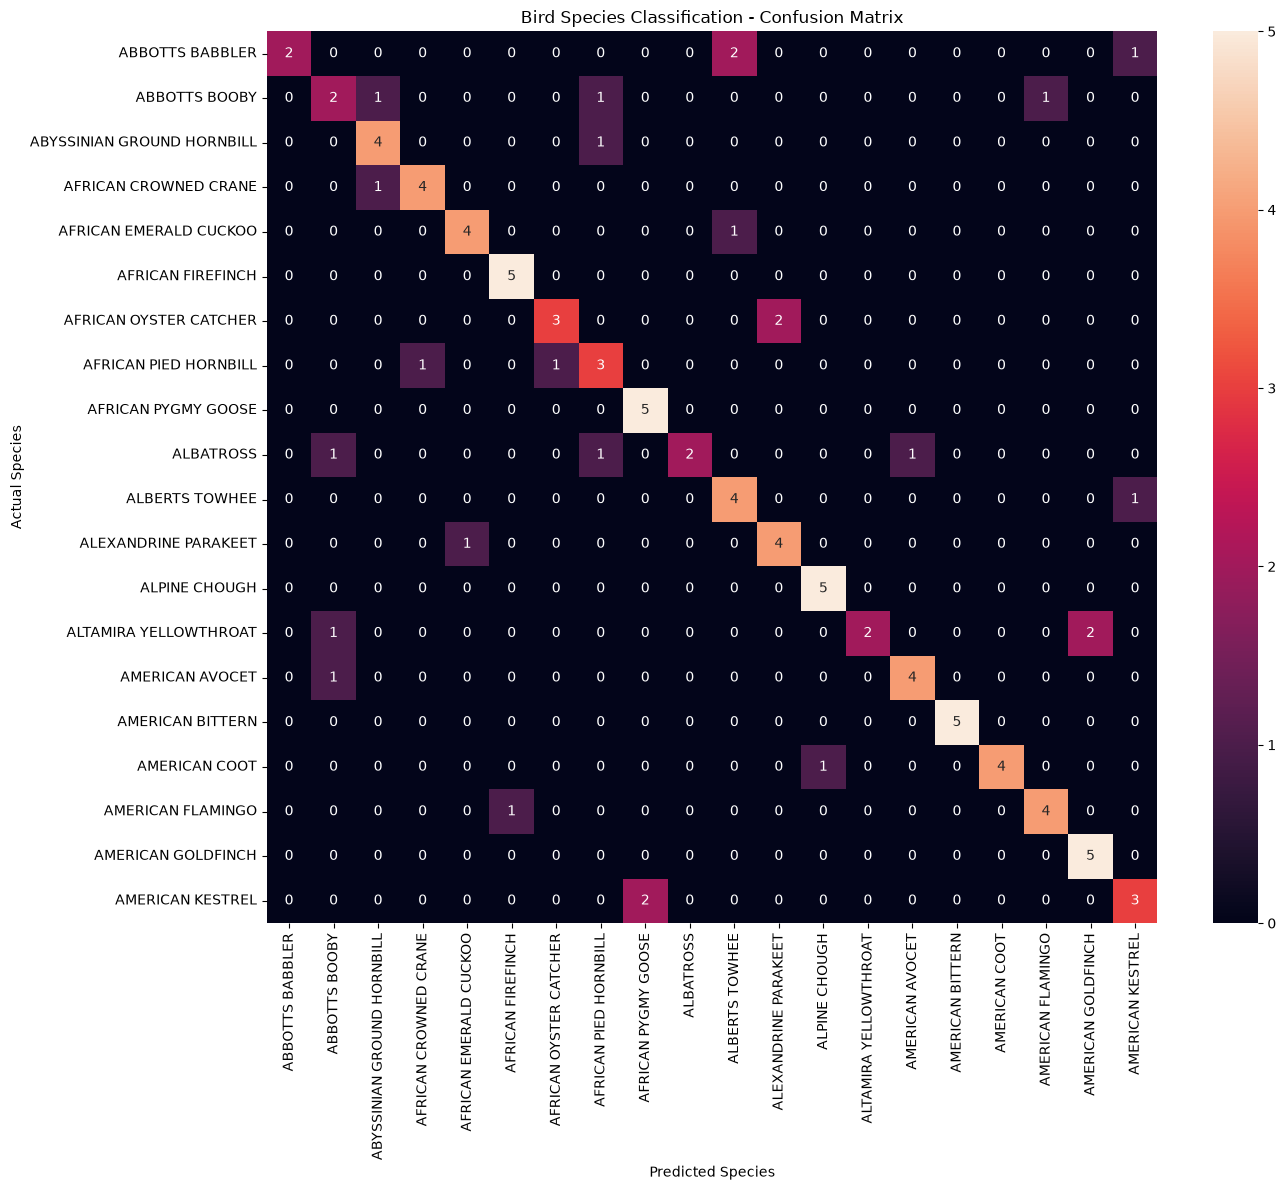

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Bird Species Classification - Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [16]:
# Save the trained model

MODEL_PATH = "../models/bird_species_cnn.keras"

model.save(MODEL_PATH)

print("Model saved successfully!")
print("Saved at:", MODEL_PATH)

Model saved successfully!
Saved at: ../models/bird_species_cnn.keras


In [17]:
import json

CLASS_NAMES_PATH = "../models/class_names.json"

with open(CLASS_NAMES_PATH, "w") as f:
    json.dump(class_names, f)

print("Class names saved successfully!")
print("Saved at:", CLASS_NAMES_PATH)

Class names saved successfully!
Saved at: ../models/class_names.json


In [18]:
# Save the trained model

model_path = "../models/bird_species_model.keras"

model.save(model_path)

print("Model saved successfully!")
print("Location:", model_path)

Model saved successfully!
Location: ../models/bird_species_model.keras


In [21]:
import os
import json

# Path to training dataset
train_dir = "../data/train"

# Get bird species names from folder names
class_names = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

print("Number of species:", len(class_names))
print("\nSpecies:")

for i, name in enumerate(class_names):
    print(i, "->", name)

# Make sure models folder exists
os.makedirs("../models", exist_ok=True)

# Save class names
with open("../models/class_names.json", "w") as f:
    json.dump(class_names, f, indent=4)

print("\nClass names saved successfully!")
print("Saved to: ../models/class_names.json")

Number of species: 20

Species:
0 -> ABBOTTS BABBLER
1 -> ABBOTTS BOOBY
2 -> ABYSSINIAN GROUND HORNBILL
3 -> AFRICAN CROWNED CRANE
4 -> AFRICAN EMERALD CUCKOO
5 -> AFRICAN FIREFINCH
6 -> AFRICAN OYSTER CATCHER
7 -> AFRICAN PIED HORNBILL
8 -> AFRICAN PYGMY GOOSE
9 -> ALBATROSS
10 -> ALBERTS TOWHEE
11 -> ALEXANDRINE PARAKEET
12 -> ALPINE CHOUGH
13 -> ALTAMIRA YELLOWTHROAT
14 -> AMERICAN AVOCET
15 -> AMERICAN BITTERN
16 -> AMERICAN COOT
17 -> AMERICAN FLAMINGO
18 -> AMERICAN GOLDFINCH
19 -> AMERICAN KESTREL

Class names saved successfully!
Saved to: ../models/class_names.json
